In [1]:
#MakeMore Part2

In [2]:
#上一节我们用两种方式实现了bigram
#效果不错，但是bigram有个明显的缺陷就是精确度不够
#因为我们的参照太少了，只根据上一个字母来推测下一个字母
#于是乎我们可以考虑添加些上下文？

In [3]:
#但是这又有个很明显的问题
#如果我们用bigram的思路，直接查表
#那么这个表格随着上下文的增长会出现指数级的增长
#比如如果我们用两个字符来决定下一个字母，那么就会出现27*27=729行
#如果用3个会直接变成27*27*27=19683行
#这显然不可接受

In [4]:
#于是本篇我们将学习使用MLP，也就是在micrograd里实现的方法来完成这个模型
#论文已经添加到文件夹下

In [5]:
# andrej这里带我们简单读了下论文
# MLP的本质就是希望模型能够“解释”单词（或者任何语言的单位，在makemore里我们的单位是字符，论文里是单词）
# 我们正常是怎么解释单词的呢？比如说：
# 如果你要给一个人解释“狗dog”这个词
# 我们会说“这和猫一样都是宠物”
# 所以其实我们会发现，语言的“解释”在很大程度上其实是“近义词”的意思
# 就是说我们并不会创造一个新的东西来解释语言
# 而是用语言本身来解释语言
# 所以说MLP的哲学就在于：既然语言本身就能解释语言，那我就去寻找这些语言间的关系
# 所以MLP给每个单词都添加了一个30维的向量，并来微调他们
# 于是乎每一个单词便有了自己在这个30维向量里的位置
# 而我们调整它们之间的位置关系，就可以用距离远近来表示它们之间的关系
# 这就是MLP的基本哲学
# 接下来我们用代码实现这个MLP

In [6]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline
#环境导入，和之前的环境是一样的，前两行是torch，后两行是画图工具

In [7]:
words=open("names.txt","r").read().splitlines()
words[:3]
#还是一样导入words

['emma', 'olivia', 'ava']

In [8]:
len(words)

32033

In [9]:
chars=sorted(list(set(''.join(words))))
stoi={s:i+1 for i,s in enumerate(chars)}
stoi['.']=0
itos={i:s for s,i in stoi.items()}
print(itos)
#还是一样建立字符数字表

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [10]:
#接下来我们要像之前一样去建造训练集
#还是一样的：一个xs一个ys一一对应
#但是这次我们要不一样一点：
#我们这次不再是单字节模式了
#也就是说我们推测下一个字符不再只看上一个字符，而是要看更多的东西

block_size=3

X,Y=[],[]

for w in words[:5]:
    
    print(w)
    context=[0]*block_size
    for ch in w+'.':
        ix=stoi[ch]
        X.append(context)
        Y.append(ix)
        print(''.join(itos[i] for i in context),"---->",itos[ix])
        context=context[1:]+[ix]
    print("========")

X=torch.tensor(X)
Y=torch.tensor(Y)

emma
... ----> e
..e ----> m
.em ----> m
emm ----> a
mma ----> .
olivia
... ----> o
..o ----> l
.ol ----> i
oli ----> v
liv ----> i
ivi ----> a
via ----> .
ava
... ----> a
..a ----> v
.av ----> a
ava ----> .
isabella
... ----> i
..i ----> s
.is ----> a
isa ----> b
sab ----> e
abe ----> l
bel ----> l
ell ----> a
lla ----> .
sophia
... ----> s
..s ----> o
.so ----> p
sop ----> h
oph ----> i
phi ----> a
hia ----> .


In [11]:
#我们可以看到，Part1是字符->字符
#现在是”字符块“->字符，逻辑类似于滚动窗口
#对于前几个字符块左边空的部分用...填充

In [12]:
#并且显然我们是可以自由调整这个字符块的大小的
block_size=10

X,Y=[],[]

for w in words[:5]:
    
    print(w)
    context=[0]*block_size
    for ch in w+'.':
        ix=stoi[ch]
        X.append(context)
        Y.append(ix)
        print(''.join(itos[i] for i in context),"---->",itos[ix])
        context=context[1:]+[ix]
    print("========")

X=torch.tensor(X)
Y=torch.tensor(Y)

emma
.......... ----> e
.........e ----> m
........em ----> m
.......emm ----> a
......emma ----> .
olivia
.......... ----> o
.........o ----> l
........ol ----> i
.......oli ----> v
......oliv ----> i
.....olivi ----> a
....olivia ----> .
ava
.......... ----> a
.........a ----> v
........av ----> a
.......ava ----> .
isabella
.......... ----> i
.........i ----> s
........is ----> a
.......isa ----> b
......isab ----> e
.....isabe ----> l
....isabel ----> l
...isabell ----> a
..isabella ----> .
sophia
.......... ----> s
.........s ----> o
........so ----> p
.......sop ----> h
......soph ----> i
.....sophi ----> a
....sophia ----> .


In [13]:
#现在的字符块就是10，可以看到...变得越来越多
#我们还是采用3作为字符块大小，这样符合论文里图示的内容

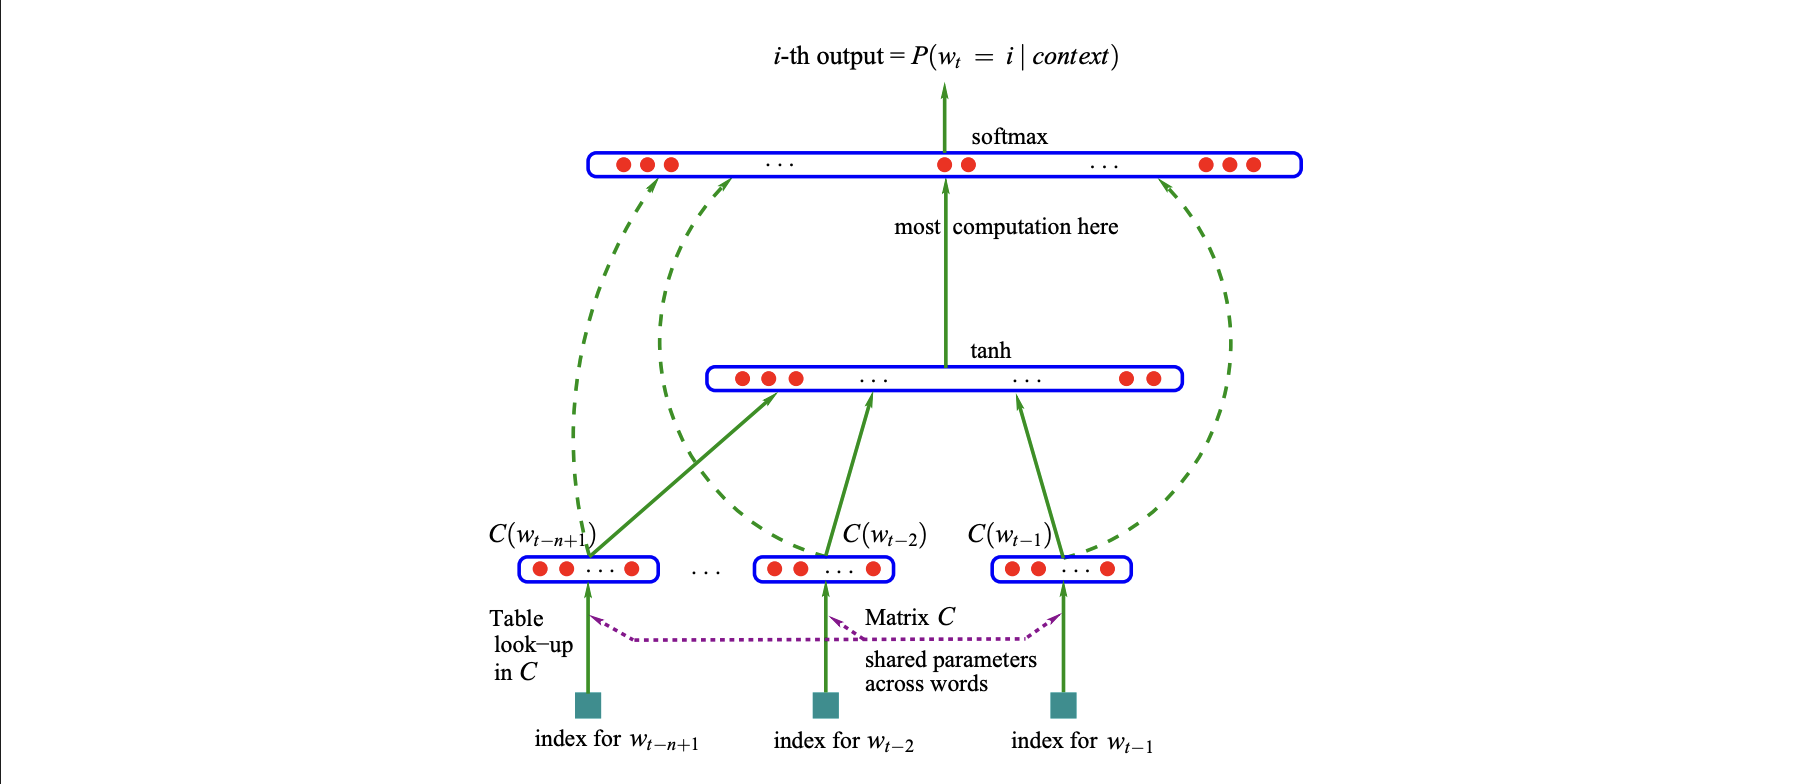

In [14]:


block_size=3

X,Y=[],[]

for w in words:
    context=[0]*block_size
    for ch in w+'.':
        ix=stoi[ch]
        X.append(context)
        Y.append(ix)
        context=context[1:]+[ix]

X=torch.tensor(X)
Y=torch.tensor(Y)

In [15]:
X.shape,X.dtype,Y.shape,Y.dtype

(torch.Size([228146, 3]), torch.int64, torch.Size([228146]), torch.int64)

In [16]:
#可以看到总共有228146个字符块和字符的一一对应

In [17]:
#接下来我们要创建论文中的”嵌入矩阵“
#具体来说就是每一个字符不在只代表一个值
#而是一个多维向量
#这里我们简单采用二维向量
C=torch.randn((27,2))
C

tensor([[ 0.4860,  0.8708],
        [-1.5348, -0.0937],
        [ 0.2550, -0.3396],
        [ 1.0877, -0.7388],
        [ 0.4426, -0.2886],
        [-0.9796, -1.3016],
        [ 0.9766,  0.3808],
        [-0.3578, -0.3790],
        [-1.0000, -0.9370],
        [ 2.2543,  0.2492],
        [ 0.2422,  0.7394],
        [-0.1467,  1.9533],
        [ 0.7738,  1.2707],
        [-1.9962,  0.1191],
        [-0.1457,  0.8648],
        [-1.4432,  0.3295],
        [ 0.7633, -2.1016],
        [ 0.1215,  1.4501],
        [ 0.6667, -0.1427],
        [-0.8286,  0.6760],
        [ 0.1149, -0.4927],
        [ 0.1541,  1.0289],
        [ 2.4756, -2.0594],
        [-0.2199, -0.1323],
        [-0.3046,  1.2177],
        [-0.2172, -1.0026],
        [ 0.1969,  1.1280]])

In [18]:
#接下来展示操作方法。比如说对于字符c，我可以去提取第三行
C[3]

tensor([ 1.0877, -0.7388])

In [19]:
#这就是c所对应的嵌入向量
#其实Part1我们就已经使用过这种方式了
#还记得独热向量吗，其实那一步的数学本质就是在取出一行向量
a=F.one_hot(torch.tensor(5),27).float()
a@C

tensor([-0.9796, -1.3016])

In [20]:
#结果是一样的

In [21]:
#但是我们刚刚只取了一行，对于X来说一次要取3行
#pytorch实现了非常强大的功能可以简便的实现这个目标
C[[5,6,7]]

tensor([[-0.9796, -1.3016],
        [ 0.9766,  0.3808],
        [-0.3578, -0.3790]])

In [22]:
#这样就一次性取出来三行了
#也可以一次性取出所有的X
emb=C[X]
emb.shape

torch.Size([228146, 3, 2])

In [23]:
#具体原理是：X[,]会取出一个数字
#再用这个数字取出C里的值去组装
X[10,1]

tensor(22)

In [24]:
C[X[10,1]]

tensor([ 2.4756, -2.0594])

In [25]:
C[22]

tensor([ 2.4756, -2.0594])

In [26]:
#可以发现C[22]和C[X[10,1]]是一样的

In [27]:
#这样的话嵌入层就完成了
#这里的话我们先只用5个单词的输入作为示例,避免后面打印的时候太长了

block_size=3

X,Y=[],[]

for w in words[:5]:
    context=[0]*block_size
    for ch in w+'.':
        ix=stoi[ch]
        X.append(context)
        Y.append(ix)
        context=context[1:]+[ix]

X=torch.tensor(X)
Y=torch.tensor(Y)
emb=C[X]
#接下来实现隐藏层

In [28]:
#首先看，这个隐藏层接收的输入会是三个输入的嵌入向量，每个嵌入向量有两个量，所以是3*2=6
#我们假设总共有100个神经元，设置W和b
W1=torch.randn((6,100))
b1=torch.rand(100)

In [29]:
#但是现在有一个问题：
emb.shape,W1.shape

(torch.Size([32, 3, 2]), torch.Size([6, 100]))

In [30]:
#emb是228146*3*2的，W1是6*100的，做不了乘法
#emb@W1+b1
#这一行会报错
#好在pytorch是一个功能强大的库
#提供了一个cat函数可以拼接张量
#还有一个unbind函数用于删除一个维度转而用元组表示

In [31]:
torch.cat([emb[:,0,:],emb[:,1,:],emb[:,2,:]],1).shape

torch.Size([32, 6])

In [32]:
torch.cat(torch.unbind(emb,1),1).shape

torch.Size([32, 6])

In [33]:
#其实torch还有一种非常高效的方式
a=torch.arange(24)
a

tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21, 22, 23])

In [34]:
a.shape

torch.Size([24])

In [35]:
a.view(2,12)

tensor([[ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11],
        [12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]])

In [36]:
a.view(4,2,3)

tensor([[[ 0,  1,  2],
         [ 3,  4,  5]],

        [[ 6,  7,  8],
         [ 9, 10, 11]],

        [[12, 13, 14],
         [15, 16, 17]],

        [[18, 19, 20],
         [21, 22, 23]]])

In [37]:
#很神奇吧，这是pytorch的view方法
#因为torch内部本身其实是线性排列的
a.storage()

/var/folders/bj/h9w4f26d58vc04wvwhk6kd580000gn/T/ipykernel_86469/3125828718.py:3: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  a.storage()


 0
 1
 2
 3
 4
 5
 6
 7
 8
 9
 10
 11
 12
 13
 14
 15
 16
 17
 18
 19
 20
 21
 22
 23
[torch.storage.TypedStorage(dtype=torch.int64, device=cpu) of size 24]

In [38]:
#所以只要view里的乘积是总数量就可以了
#而且view有个很高效的地方在于：它是在原地进行操作的
#之前的两个操作都会创建新的对象占用内存空间

In [39]:
#所以现在回过头来发现其实一个view()就可以了
emb.shape

torch.Size([32, 3, 2])

In [40]:
emb.view(32,6).shape

torch.Size([32, 6])

In [41]:
#还有更方便的，torch可以自己推理，用-1就是告诉torch这里要填一个符合最终惩罚结果的数字
emb.view(-1,6).shape

torch.Size([32, 6])

In [42]:
#这样就可以用乘法了
h=emb.view(-1,6) @ W1 + b1
#这里也要小心！
#b1的形状是(100)
#所以这里会涉及到广播机制
#32 100
#100
#根据广播机制b1会扩展成32 100
#所以是可行的
h.shape

torch.Size([32, 100])

In [43]:
h

tensor([[ 2.9174,  5.1550,  0.7623,  ..., -0.3541,  1.8417, -1.3915],
        [ 2.2109, -0.8507,  2.1432,  ...,  3.7348, -1.0783, -2.4745],
        [-1.0562, -1.4792,  4.6062,  ..., -0.4997, -1.5150,  1.2852],
        ...,
        [-2.5637, -6.8240,  0.6960,  ...,  3.1880,  1.6713,  0.1210],
        [-2.5369,  2.6496, -3.5631,  ..., -5.4420,  3.3041,  3.1729],
        [ 2.0998, -4.6179, -0.0080,  ...,  6.3803, -0.1316, -0.5198]])

In [44]:
#神经网络最后一步还需要tanh来平滑化
h=torch.tanh(h)
h

tensor([[ 0.9942,  0.9999,  0.6424,  ..., -0.3400,  0.9510, -0.8835],
        [ 0.9763, -0.6914,  0.9729,  ...,  0.9989, -0.7926, -0.9859],
        [-0.7842, -0.9013,  0.9998,  ..., -0.4619, -0.9078,  0.8579],
        ...,
        [-0.9882, -1.0000,  0.6018,  ...,  0.9966,  0.9317,  0.1204],
        [-0.9876,  0.9901, -0.9984,  ..., -1.0000,  0.9973,  0.9965],
        [ 0.9704, -0.9998, -0.0080,  ...,  1.0000, -0.1308, -0.4775]])

In [45]:
#于是我们就得到了隐藏层激活值

In [46]:
#好的接下来我们来创建最后一个输出层
#这一层应该接住隐藏层传过来的激活值然后输出logits
W2=torch.randn((100,27))
b2=torch.randn(27)

In [47]:
logits=h@W2+b2

In [48]:
logits.shape

torch.Size([32, 27])

In [49]:
#接下来就是softmax
counts=logits.exp()
probs=counts/counts.sum(1,keepdims=True)
probs.shape

torch.Size([32, 27])

In [50]:
#接下来就是用Y找到那些正确答案的概率
probs[torch.arange(32),Y]

tensor([1.3719e-09, 6.4766e-01, 4.1948e-02, 2.1006e-13, 9.9837e-01, 1.0190e-15,
        1.6909e-07, 3.8681e-10, 7.7125e-12, 1.3225e-09, 2.6094e-04, 3.0865e-10,
        1.3602e-05, 5.4237e-11, 6.9713e-13, 3.4765e-10, 8.3758e-08, 1.3568e-10,
        2.0301e-06, 3.7448e-10, 6.6270e-02, 1.0920e-07, 1.2587e-12, 1.2937e-07,
        5.2365e-05, 2.1553e-11, 2.3394e-11, 4.8723e-02, 1.0380e-09, 1.1799e-11,
        1.5119e-05, 4.0471e-08])

In [51]:
#理想状态下，这些数值应该趋近于1
#所以下一步就是开始训练

In [52]:
#首先计算loss
loss=-probs[torch.arange(32),Y].log().mean()
loss

tensor(17.4222)

In [53]:
#现在前向传播就完成了
#整理下代码

In [54]:
g = torch.Generator().manual_seed(2147483647) #固定随机数
C = torch.randn((27, 2), generator=g)#嵌入层
W1 = torch.randn((6, 100), generator=g)#隐藏层
b1 = torch.randn(100, generator=g)#隐藏层
W2 = torch.randn((100, 27), generator=g)#激活层
b2 = torch.randn(27, generator=g)#激活层
parameters = [C, W1, b1, W2, b2]#所有的总参数，用于后续的梯度清除
for p in parameters:
    p.requires_grad=True

In [55]:
sum(p.nelement() for p in parameters) #总参数量

3481

In [56]:
emb = C[X] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
counts = logits.exp()
prob = counts / counts.sum(1, keepdims=True)
loss = -prob[torch.arange(32), Y].log().mean()
loss

tensor(17.7697, grad_fn=<NegBackward0>)

In [57]:
#同时，pytorch实现了我们最后从logits到loss的那一步
#这一步就是cross_entropy,中文翻译交叉_熵
emb = C[X] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss=F.cross_entropy(logits,Y)
loss

tensor(17.7697, grad_fn=<NllLossBackward0>)

In [58]:
#同时这一步由于是pytorch的内部方法所以pytorch在里面可以高效地简化反向传播
#并且cross_entropy在面对极大数，比如出现e**100的时候按传统写法会出现nan但是cross_entropy可以很好的处理这些极端情况

In [59]:
#现在前向传播完成，接下来就是清空梯度，反向传播

In [60]:
#反向传播
for p in parameters:
    p.grad=None
loss.backward()
for p in parameters:
    p.data+=-0.1*p.grad

In [61]:
#接下来组合一下
for _ in range(10):
    emb = C[X] # (32, 3, 2)
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 100)
    logits = h @ W2 + b2 # (32, 27)
    loss=F.cross_entropy(logits,Y)

    print(loss.item())
    #反向传播
    for p in parameters:
        p.grad=None
    loss.backward()
    for p in parameters:
        p.data+=-0.1*p.grad

13.656402587890625
11.298770904541016
9.4524564743042
7.984263896942139
6.891321659088135
6.1000142097473145
5.452035903930664
4.898152828216553
4.414663791656494
3.985849142074585


In [62]:
#loss下降到了4左右，如果多训练
for _ in range(1000):
    emb = C[X] # (32, 3, 2)
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 100)
    logits = h @ W2 + b2 # (32, 27)
    loss=F.cross_entropy(logits,Y)

    #反向传播
    for p in parameters:
        p.grad=None
    loss.backward()
    for p in parameters:
        p.data+=-0.1*p.grad

print(loss.item())

0.2560918927192688


In [63]:
#可以发现loss非常的低，拟合度很高
#但这个是因为我们现在的数据量太小了
#只拟合32个当然很好了
logits.max(1),Y

(torch.return_types.max(
 values=tensor([13.3518, 17.8061, 20.5914, 20.6164, 16.7517, 13.3518, 15.9871, 14.1991,
         15.9261, 18.4037, 15.9549, 20.9417, 13.3518, 17.1368, 17.1637, 20.0786,
         13.3518, 16.4702, 15.1487, 17.0690, 18.6017, 15.9800, 10.8867, 10.6986,
         15.5148, 13.3518, 16.2503, 16.9685, 12.7510, 16.2235, 19.0987, 16.0391],
        grad_fn=<MaxBackward0>),
 indices=tensor([ 9, 13, 13,  1,  0,  9, 12,  9, 22,  9,  1,  0,  9, 22,  1,  0,  9, 19,
          1,  2,  5, 12, 12,  1,  0,  9, 15, 16,  8,  9,  1,  0])),
 tensor([ 5, 13, 13,  1,  0, 15, 12,  9, 22,  9,  1,  0,  1, 22,  1,  0,  9, 19,
          1,  2,  5, 12, 12,  1,  0, 19, 15, 16,  8,  9,  1,  0]))

In [64]:
#这个是logits给出的最大值的预测，可以发现大部分和正确答案Y拟合的很好
#所以下一步我们就是实现全部的训练

In [65]:
block_size=3

X,Y=[],[]

for w in words:
    context=[0]*block_size
    for ch in w+'.':
        ix=stoi[ch]
        X.append(context)
        Y.append(ix)
        context=context[1:]+[ix]

X=torch.tensor(X)
Y=torch.tensor(Y)

for _ in range(10):
    emb = C[X] # (32, 3, 2)
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 100)
    logits = h @ W2 + b2 # (32, 27)
    loss=F.cross_entropy(logits,Y)
    print(loss.item())
    #反向传播
    for p in parameters:
        p.grad=None
    loss.backward()
    for p in parameters:
        p.data+=-0.1*p.grad

13.646496772766113
13.094270706176758
12.58001708984375
12.099854469299316
11.653829574584961
11.243758201599121
10.868659019470215
10.525008201599121
10.21104621887207
9.924517631530762


In [66]:
#可以看到这次训练慢一些而且loss下降比较缓慢了
#我们加长一下训练规模

In [67]:
block_size=3

X,Y=[],[]

for w in words:
    context=[0]*block_size
    for ch in w+'.':
        ix=stoi[ch]
        X.append(context)
        Y.append(ix)
        context=context[1:]+[ix]

X=torch.tensor(X)
Y=torch.tensor(Y)

for i in range(100):
    emb = C[X] # (32, 3, 2)
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 100)
    logits = h @ W2 + b2 # (32, 27)
    loss=F.cross_entropy(logits,Y)
    if i%5==0:
        print(f"训练轮次:{i},loss={loss.item():.4f}")
    #反向传播
    for p in parameters:
        p.grad=None
    loss.backward()
    for p in parameters:
        p.data+=-0.1*p.grad
print(f"最终结果:loss={loss}")

训练轮次:0,loss=9.6609
训练轮次:5,loss=8.5985
训练轮次:10,loss=7.8184
训练轮次:15,loss=7.1950
训练轮次:20,loss=6.6787
训练轮次:25,loss=6.2464
训练轮次:30,loss=5.8847
训练轮次:35,loss=5.5809
训练轮次:40,loss=5.3233
训练轮次:45,loss=5.1020
训练轮次:50,loss=4.9096
训练轮次:55,loss=4.7409
训练轮次:60,loss=4.5922
训练轮次:65,loss=4.4607
训练轮次:70,loss=4.3433
训练轮次:75,loss=4.2375
训练轮次:80,loss=4.1409
训练轮次:85,loss=4.0521
训练轮次:90,loss=3.9700
训练轮次:95,loss=3.8939
最终结果:loss=3.836977243423462


In [68]:
#运行的时候可以发现运算时间相较于之前长了不少
#甚至我的m5芯片的macbookair都有很明显的发烫了（lol）
#但是chatgpt其实用了数以万亿计的互联网文本作为参考，但是我们现在只有几千个参数，几万个训练对象就开始发烫
#所以我们的思路是：不直接训练所有的对象，而是分批次训练这个模型
#实现方法是随机抽取训练集里的一个个小部分去进行训练

In [69]:
#torch实现了随机整数的功能
torch.randint(0,5,(32,))#最后一个数量参数要是元组

tensor([2, 4, 2, 4, 0, 4, 1, 1, 1, 2, 3, 3, 4, 4, 2, 4, 3, 3, 3, 4, 4, 1, 3, 0,
        1, 3, 2, 3, 2, 4, 3, 1])

In [70]:
torch.randint(1,X.shape[0],(32,))

tensor([135496, 189192, 167984,   9685,   8657, 220609,  22639, 165862, 139164,
        165556, 162385, 111079, 130913,   6098, 159492, 150325, 159089,  49040,
          5333, 207304, 227898, 196393,  31232, 125886,  10740, 139957, 159620,
          2348, 161684,  96241, 171258, 211578])

In [71]:
#这里就生成了一个大小为32的小批量训练集
#我们可以先用这个来训练

for i in range(100):
    ix=torch.randint(1,X.shape[0],(32,))
    emb = C[X[ix]] # (32, 3, 2)
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 100)
    logits = h @ W2 + b2 # (32, 27)
    loss=F.cross_entropy(logits,Y[ix])
    if i%5==0:
        print(f"训练轮次:{i},loss={loss.item():.4f}")
    #反向传播
    for p in parameters:
        p.grad=None
    loss.backward()
    for p in parameters:
        p.data+=-0.1*p.grad

emb = C[X] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss=F.cross_entropy(logits,Y)       
print(f"最终结果:整体loss={loss}")

训练轮次:0,loss=3.6477
训练轮次:5,loss=4.0443
训练轮次:10,loss=4.1115
训练轮次:15,loss=4.1889
训练轮次:20,loss=3.6797
训练轮次:25,loss=3.9211
训练轮次:30,loss=3.4021
训练轮次:35,loss=3.8881
训练轮次:40,loss=2.7253
训练轮次:45,loss=3.4036
训练轮次:50,loss=3.1864
训练轮次:55,loss=3.4127
训练轮次:60,loss=3.4063
训练轮次:65,loss=3.5473
训练轮次:70,loss=3.2142
训练轮次:75,loss=3.1798
训练轮次:80,loss=3.3416
训练轮次:85,loss=3.5010
训练轮次:90,loss=2.8311
训练轮次:95,loss=4.2412
最终结果:整体loss=3.255357265472412


In [72]:
#这次就快了很多
#但是会发现我们的loss出现了起伏
#因为这个训练过程不是固定的，会随机取训练对象
#所以要是随机取到了没怎么训练过的内容就会出现loss倒转
#我们最后计算整体的loss就好了

In [73]:
#让我们多算几遍
for i in range(10000):
    ix=torch.randint(1,X.shape[0],(32,))
    emb = C[X[ix]] # (32, 3, 2)
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 100)
    logits = h @ W2 + b2 # (32, 27)
    loss=F.cross_entropy(logits,Y[ix])

    #反向传播
    for p in parameters:
        p.grad=None
    loss.backward()
    for p in parameters:
        p.data+=-0.1*p.grad
    if i%500==0:
        print(f"训练轮次:{i},loss={loss.item():.4f}")
        emb = C[X] # (32, 3, 2)
        h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 100)
        logits = h @ W2 + b2 # (32, 27)
        loss=F.cross_entropy(logits,Y)       
        print(f"整体loss={loss}\n")

emb = C[X] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss=F.cross_entropy(logits,Y)       
print(f"最终结果:整体loss={loss}")

训练轮次:0,loss=3.2202
整体loss=3.216106653213501

训练轮次:500,loss=2.9380
整体loss=2.7283570766448975

训练轮次:1000,loss=2.6896
整体loss=2.702104091644287

训练轮次:1500,loss=2.6530
整体loss=2.5912253856658936

训练轮次:2000,loss=2.4671
整体loss=2.5493507385253906

训练轮次:2500,loss=2.7595
整体loss=2.6051483154296875

训练轮次:3000,loss=2.2719
整体loss=2.5365469455718994

训练轮次:3500,loss=2.3227
整体loss=2.536111354827881

训练轮次:4000,loss=2.4761
整体loss=2.5000672340393066

训练轮次:4500,loss=2.5756
整体loss=2.5313632488250732

训练轮次:5000,loss=2.4276
整体loss=2.500225067138672

训练轮次:5500,loss=2.0953
整体loss=2.5108511447906494

训练轮次:6000,loss=2.4980
整体loss=2.5002944469451904

训练轮次:6500,loss=2.8130
整体loss=2.503714084625244

训练轮次:7000,loss=2.1812
整体loss=2.562519073486328

训练轮次:7500,loss=2.3736
整体loss=2.4865942001342773

训练轮次:8000,loss=2.8007
整体loss=2.460705518722534

训练轮次:8500,loss=2.3364
整体loss=2.5116360187530518

训练轮次:9000,loss=2.6016
整体loss=2.4504897594451904

训练轮次:9500,loss=2.6234
整体loss=2.4839537143707275

最终结果:整体loss=2.499777317047119


In [74]:
#我们可以发现：整体loss并没有稳步下降，说明我们在步长上的设计是有问题的
#这里选择步长的方法非常简单粗暴：直接试试看不同的取值loss是怎么变的
#重置参数
g = torch.Generator().manual_seed(2147483647) #固定随机数
C = torch.randn((27, 2), generator=g)#嵌入层
W1 = torch.randn((6, 100), generator=g)#隐藏层
b1 = torch.randn(100, generator=g)#隐藏层
W2 = torch.randn((100, 27), generator=g)#激活层
b2 = torch.randn(27, generator=g)#激活层
parameters = [C, W1, b1, W2, b2]#所有的总参数，用于后续的梯度清除
for p in parameters:
    p.requires_grad=True

block_size=3

X,Y=[],[]

for w in words:
    context=[0]*block_size
    for ch in w+'.':
        ix=stoi[ch]
        X.append(context)
        Y.append(ix)
        context=context[1:]+[ix]

X=torch.tensor(X)
Y=torch.tensor(Y)

for i in range(100):
    ix=torch.randint(1,X.shape[0],(32,))
    emb = C[X[ix]] # (32, 3, 2)
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 100)
    logits = h @ W2 + b2 # (32, 27)
    loss=F.cross_entropy(logits,Y[ix])

    #反向传播
    for p in parameters:
        p.grad=None
    loss.backward()
    for p in parameters:

        #先来试试看0.001
        p.data+=-0.001*p.grad
        
    emb = C[X] # (32, 3, 2)
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 100)
    logits = h @ W2 + b2 # (32, 27)
    loss=F.cross_entropy(logits,Y)       
    print(f"训练轮次:{i},loss={loss.item():.4f}")
        
emb = C[X] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss=F.cross_entropy(logits,Y)       
print(f"最终结果:整体loss={loss}")

训练轮次:0,loss=19.4639
训练轮次:1,loss=19.4223
训练轮次:2,loss=19.3827
训练轮次:3,loss=19.3558
训练轮次:4,loss=19.3079
训练轮次:5,loss=19.2664
训练轮次:6,loss=19.2319
训练轮次:7,loss=19.2033
训练轮次:8,loss=19.1674
训练轮次:9,loss=19.1289
训练轮次:10,loss=19.0995
训练轮次:11,loss=19.0751
训练轮次:12,loss=19.0489
训练轮次:13,loss=19.0084
训练轮次:14,loss=18.9657
训练轮次:15,loss=18.9281
训练轮次:16,loss=18.8848
训练轮次:17,loss=18.8577
训练轮次:18,loss=18.8329
训练轮次:19,loss=18.8114
训练轮次:20,loss=18.7871
训练轮次:21,loss=18.7671
训练轮次:22,loss=18.7375
训练轮次:23,loss=18.7084
训练轮次:24,loss=18.6848
训练轮次:25,loss=18.6678
训练轮次:26,loss=18.6398
训练轮次:27,loss=18.6120
训练轮次:28,loss=18.5960
训练轮次:29,loss=18.5707
训练轮次:30,loss=18.5442
训练轮次:31,loss=18.5246
训练轮次:32,loss=18.4960
训练轮次:33,loss=18.4750
训练轮次:34,loss=18.4461
训练轮次:35,loss=18.4157
训练轮次:36,loss=18.3786
训练轮次:37,loss=18.3521
训练轮次:38,loss=18.3281
训练轮次:39,loss=18.3088
训练轮次:40,loss=18.2875
训练轮次:41,loss=18.2598
训练轮次:42,loss=18.2349
训练轮次:43,loss=18.2167
训练轮次:44,loss=18.1940
训练轮次:45,loss=18.1747
训练轮次:46,loss=18.1534
训练轮次:47,loss=18.1286
训练

In [75]:
#loss下降太慢了，试试-1
#我们可以发现：整体loss并没有稳步下降，说明我们在步长上的设计是有问题的
#这里选择步长的方法非常简单粗暴：直接试试看不同的取值loss是怎么变的
#重置参数
g = torch.Generator().manual_seed(2147483647) #固定随机数
C = torch.randn((27, 2), generator=g)#嵌入层
W1 = torch.randn((6, 100), generator=g)#隐藏层
b1 = torch.randn(100, generator=g)#隐藏层
W2 = torch.randn((100, 27), generator=g)#激活层
b2 = torch.randn(27, generator=g)#激活层
parameters = [C, W1, b1, W2, b2]#所有的总参数，用于后续的梯度清除
for p in parameters:
    p.requires_grad=True

block_size=3

X,Y=[],[]

for w in words:
    context=[0]*block_size
    for ch in w+'.':
        ix=stoi[ch]
        X.append(context)
        Y.append(ix)
        context=context[1:]+[ix]

X=torch.tensor(X)
Y=torch.tensor(Y)

for i in range(100):
    ix=torch.randint(1,X.shape[0],(32,))
    emb = C[X[ix]] # (32, 3, 2)
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 100)
    logits = h @ W2 + b2 # (32, 27)
    loss=F.cross_entropy(logits,Y[ix])

    #反向传播
    for p in parameters:
        p.grad=None
    loss.backward()
    for p in parameters:

        #再试试-1
        p.data+=-1*p.grad
        
    emb = C[X] # (32, 3, 2)
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 100)
    logits = h @ W2 + b2 # (32, 27)
    loss=F.cross_entropy(logits,Y)       
    print(f"训练轮次:{i},loss={loss.item():.4f}")
        
emb = C[X] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss=F.cross_entropy(logits,Y)       
print(f"最终结果:整体loss={loss}")

训练轮次:0,loss=16.2306
训练轮次:1,loss=13.7039
训练轮次:2,loss=12.9028
训练轮次:3,loss=13.9013
训练轮次:4,loss=12.1997
训练轮次:5,loss=12.6025
训练轮次:6,loss=12.6623
训练轮次:7,loss=10.7770
训练轮次:8,loss=12.2404
训练轮次:9,loss=12.4769
训练轮次:10,loss=12.0471
训练轮次:11,loss=11.6102
训练轮次:12,loss=11.9060
训练轮次:13,loss=9.6967
训练轮次:14,loss=9.7771
训练轮次:15,loss=9.7011
训练轮次:16,loss=8.6107
训练轮次:17,loss=9.4684
训练轮次:18,loss=9.2851
训练轮次:19,loss=8.5984
训练轮次:20,loss=8.2893
训练轮次:21,loss=10.6449
训练轮次:22,loss=11.7453
训练轮次:23,loss=10.2796
训练轮次:24,loss=10.0672
训练轮次:25,loss=11.0804
训练轮次:26,loss=9.6407
训练轮次:27,loss=10.6961
训练轮次:28,loss=10.1334
训练轮次:29,loss=8.3000
训练轮次:30,loss=8.1338
训练轮次:31,loss=10.1528
训练轮次:32,loss=8.6916
训练轮次:33,loss=9.5633
训练轮次:34,loss=8.5627
训练轮次:35,loss=7.8971
训练轮次:36,loss=9.0167
训练轮次:37,loss=8.5700
训练轮次:38,loss=7.5339
训练轮次:39,loss=7.9856
训练轮次:40,loss=7.8806
训练轮次:41,loss=7.9336
训练轮次:42,loss=7.6944
训练轮次:43,loss=8.6917
训练轮次:44,loss=9.3713
训练轮次:45,loss=8.5032
训练轮次:46,loss=8.7772
训练轮次:47,loss=7.6003
训练轮次:48,loss=8.0926
训练轮次:49,l

In [76]:
#这里显然发现loss开始上下波动，说明步长太长了，就像是如果我们想要走路走到某个特定的点的话，如果步长太长会很难精确走到这个点而是前后来回走
#这样我们可以初步判断：最合理的步长至少应该是出现在0.01~1之间的
#torch实现了一种功能来帮我们遍历步长

In [77]:
torch.linspace(0.001,1,100)

tensor([0.0010, 0.0111, 0.0212, 0.0313, 0.0414, 0.0515, 0.0615, 0.0716, 0.0817,
        0.0918, 0.1019, 0.1120, 0.1221, 0.1322, 0.1423, 0.1524, 0.1625, 0.1725,
        0.1826, 0.1927, 0.2028, 0.2129, 0.2230, 0.2331, 0.2432, 0.2533, 0.2634,
        0.2735, 0.2835, 0.2936, 0.3037, 0.3138, 0.3239, 0.3340, 0.3441, 0.3542,
        0.3643, 0.3744, 0.3845, 0.3945, 0.4046, 0.4147, 0.4248, 0.4349, 0.4450,
        0.4551, 0.4652, 0.4753, 0.4854, 0.4955, 0.5055, 0.5156, 0.5257, 0.5358,
        0.5459, 0.5560, 0.5661, 0.5762, 0.5863, 0.5964, 0.6065, 0.6165, 0.6266,
        0.6367, 0.6468, 0.6569, 0.6670, 0.6771, 0.6872, 0.6973, 0.7074, 0.7175,
        0.7275, 0.7376, 0.7477, 0.7578, 0.7679, 0.7780, 0.7881, 0.7982, 0.8083,
        0.8184, 0.8285, 0.8385, 0.8486, 0.8587, 0.8688, 0.8789, 0.8890, 0.8991,
        0.9092, 0.9193, 0.9294, 0.9395, 0.9495, 0.9596, 0.9697, 0.9798, 0.9899,
        1.0000])

In [78]:
#这样就可以在0.001~1之间遍历1000个数字
#但是我们思考一下：我们的loss不是线性分布的，而是有指数关系的，所以我们的步长增长肯定也要不均匀才合理
lre=torch.linspace(-3,0,1000)
lrs=10**lre

In [79]:
#这样的变化明显就合理很多，越靠近-0.001变化就越小

In [80]:
#所以接下来我们在训练中添加这种步长的变化
lri=[]
lossi=[]
for i in range(1000):
    ix=torch.randint(1,X.shape[0],(32,))
    emb = C[X[ix]] # (32, 3, 2)
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 100)
    logits = h @ W2 + b2 # (32, 27)
    loss=F.cross_entropy(logits,Y[ix])
    #反向传播
    for p in parameters:
        p.grad=None
    loss.backward()

    lr=lrs[i]
    for p in parameters:
        p.data+=-lr*p.grad

    lri.append(lr)
    lossi.append(loss.item())

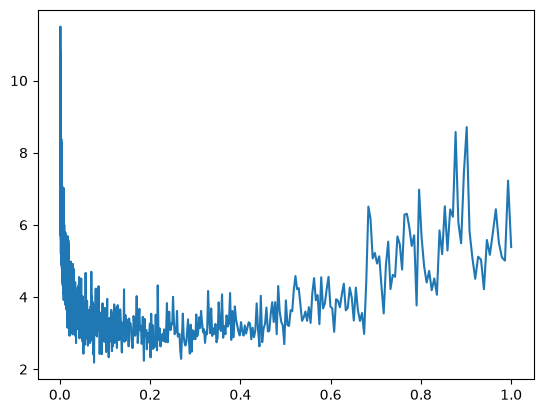

In [81]:
plt.plot(lri,lossi)

In [82]:
#我们可以看到这个loss曲线的分布
#一开始步长很小，所以loss变化也不大
#到了某一个区间突然开始发力，loss猛猛掉
#然后超过了某一个阈值开始不稳定了，于是开始飘忽不定了
#但是同时会发现这个东西他在横轴上是指数分布的
#所以我们可以换一个坐标看看

In [83]:
lri=[]
lossi=[]
for i in range(1000):
    ix=torch.randint(1,X.shape[0],(32,))
    emb = C[X[ix]] # (32, 3, 2)
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 100)
    logits = h @ W2 + b2 # (32, 27)
    loss=F.cross_entropy(logits,Y[ix])
    #反向传播
    for p in parameters:
        p.grad=None
    loss.backward()

    lr=lrs[i]
    for p in parameters:
        p.data+=-lr*p.grad

    lri.append(lre[i])#横坐标换成-3～0的均匀分布
    lossi.append(loss.item())

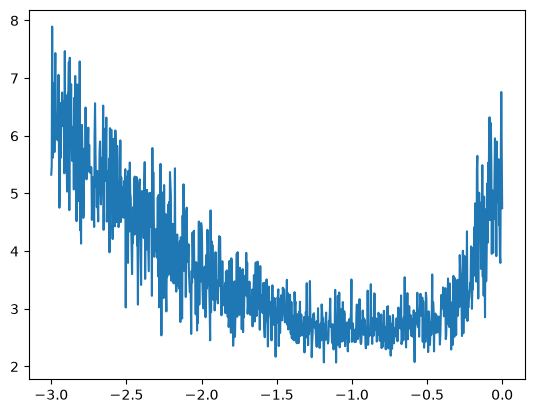

In [84]:
plt.plot(lri,lossi)

In [85]:
#这个就容易看很多了，可以看到loss在稳步下降，过了某个阈值之后开始急剧上升，说明不稳定了
#大概估计一下，步长设置在-0.1左右就很不错
#那我们重新来训练

In [86]:
g = torch.Generator().manual_seed(2147483647) #固定随机数
C = torch.randn((27, 2), generator=g)#嵌入层
W1 = torch.randn((6, 100), generator=g)#隐藏层
b1 = torch.randn(100, generator=g)#隐藏层
W2 = torch.randn((100, 27), generator=g)#激活层
b2 = torch.randn(27, generator=g)#激活层
parameters = [C, W1, b1, W2, b2]#所有的总参数，用于后续的梯度清除
for p in parameters:
    p.requires_grad=True

block_size=3

X,Y=[],[]

for w in words:
    context=[0]*block_size
    for ch in w+'.':
        ix=stoi[ch]
        X.append(context)
        Y.append(ix)
        context=context[1:]+[ix]

X=torch.tensor(X)
Y=torch.tensor(Y)

In [91]:
for i in range(100000):
    ix=torch.randint(1,X.shape[0],(32,))
    emb = C[X[ix]] # (32, 3, 2)
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 100)
    logits = h @ W2 + b2 # (32, 27)
    loss=F.cross_entropy(logits,Y[ix])
    #反向传播
    for p in parameters:
        p.grad=None
    loss.backward()

    for p in parameters:
        p.data+=-0.1*p.grad

emb = C[X] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss=F.cross_entropy(logits,Y)       
print(f"最终结果:整体loss={loss}")

最终结果:整体loss=2.253726005554199


In [92]:
#可以看到我们的最终loss已经低于之前的bigram了，说明我们的训练卓有成效
#可以反复运行上一个单元格，会发现loss在一直下降

In [ ]:
#并且在真实训练中我们往往在训练后期会采用比较低的梯度，这样的话可以有效地精确训练
for i in range(100000):
    ix=torch.randint(1,X.shape[0],(32,))
    emb = C[X[ix]] # (32, 3, 2)
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 100)
    logits = h @ W2 + b2 # (32, 27)
    loss=F.cross_entropy(logits,Y[ix])
    #反向传播
    for p in parameters:
        p.grad=None
    loss.backward()

    for p in parameters:
        p.data+=-0.01*p.grad

emb = C[X] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss=F.cross_entropy(logits,Y)       
print(f"最终结果:整体loss={loss}")